# Resumen: Calidad del dato

La calidad intrínseca de los datos (lógica y completitud) es alta. Sin embargo, existía sesgo de redundancia (17.36% de filas duplicadas). Tras limpieza, el dataset resultante (aprox. 3.6M de registros) es fiable para exploración válida.

---

## Variables transversales

- **Duplicados:** Gran volumen de registros idénticos (~750k) eliminados.

- **valores erróneos:** Casos mínimos sin impacto relevante.

- **Nulos:** Concentrados en variables de reviews. El resto (<1%) puede permitir imputaciones simples.

- **Outliers:** Representan la realidad del mercado (picos de precio, demanda, lluvia atípica) y se mantienen intactos.

- **Categóricas:** Limpias y estandarizadas.

---

## Dimensión Temporal

- Cobertura completa diaria, sin valores faltantes.
- Alta variabilidad de registro de observaciones por día.

---

## Dimensión Espacial

- Registros geolocalizados únicos y válidos.
- Efecto borde reducido y sin impacto significativo del MAUP (barrio como ud de agregación fiable)

# 0. Conexión con proyecto e importación de dataset

In [14]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
from quality_checkers import *

In [3]:
from google.cloud import bigquery
client = bigquery.Client(project="project3grupo1")

In [4]:
query = """
SELECT *
FROM `project3grupo1.dbt_transform.mart_occupancy_features`
"""

df_raw = client.query(query).to_dataframe()

# 1. Calidad del dato variables transversales

## 1.1 Clase validación de valores - tratamiento de valores erróneos variables continuas

formato se da por válido tras la ingesta

In [5]:
base_validator = BaseQualityValidator()

## 1.2 Clase identificadora de nulos, outliers y duplicados variables continuas

In [6]:
analyzer = TabularNullOutliers()

## 1.3 Clase estandarizadora variables categóricas - sin transformaciones para modelado

In [7]:
analyzer_cat = CategoricalQualityValidator()

# 2. Validación calidad de la variable temporal

In [8]:
analyzer_temp = TemporalQualityValidator()

# 3. Validación calidad variable espacial

In [9]:
# df_barrios = pd.read_csv("/content/BarcelonaCiutat_Barris.csv")
df_barrios = pd.read_csv(r"D:\yannis_data\Descargas\BarcelonaCiutat_Barris.csv")
# https://opendata-ajuntament.barcelona.cat/data/es/dataset/20170706-districtes-barris/resource/b21fa550-56ea-4f4c-9adc-b8009381896e

In [10]:
distritos_gdf = gpd.GeoDataFrame(df_barrios,
    geometry=gpd.GeoSeries.from_wkt(df_barrios['geometria_wgs84'],
    crs="EPSG:4326")).to_crs(epsg=3857) #CRS = sistema de coordenadas

# Normalizar nombres barrios en ambos barrios
distritos_gdf['key'] = distritos_gdf['nom_barri'].str.lower().str.strip()

# Agrupar puntos por nombre barrio
conteo_barrios = df_raw.groupby('neighbourhood_cleansed').size().reset_index(name='count')
conteo_barrios['key'] = conteo_barrios['neighbourhood_cleansed'].str.lower().str.strip()

# Mergeo de barrios bcn con conteo de puntos por nombre barrio
gdf_mapa = distritos_gdf.merge(conteo_barrios, on='key', how='left')

In [ ]:
spatial_val = SpatialQualityValidator()

# 4. Ejecución pipeline y dataset pre-EDA

[-] Eliminadas 1065 filas con 'bedrooms' fuera de rango [0, 20].
[-] Eliminadas 245 filas con 'beds' fuera de rango [0, 50].
[-] Eliminadas 1880 filas con 'minimum_nights' fuera de rango [1, 365].
-------------------------------------------------------
[+] Validación completada.
    Filas originales: 4369397
    Filas retenidas:  4366207
    Tasa de retención: 99.93%


FILAS DUPLICADAS
[-] Se encontraron 757906 filas duplicadas (17.36% del total).
[+] Duplicados eliminados. Filas restantes: 3608301
--------------------------------------------------

VALORES NULOS
                  Columna  Nulos  Porcentaje (%)
review_scores_cleanliness 686789           19.03
     review_scores_rating 686544           19.03
   review_scores_location 686544           19.03
      review_scores_value 686544           19.03
                     beds  17378            0.48
                 temp_max  13165            0.36
                temp_mean  13165            0.36
                 temp_min  13165      

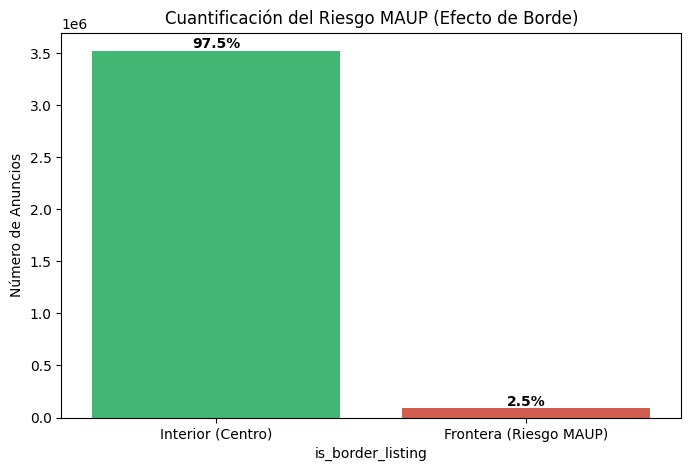

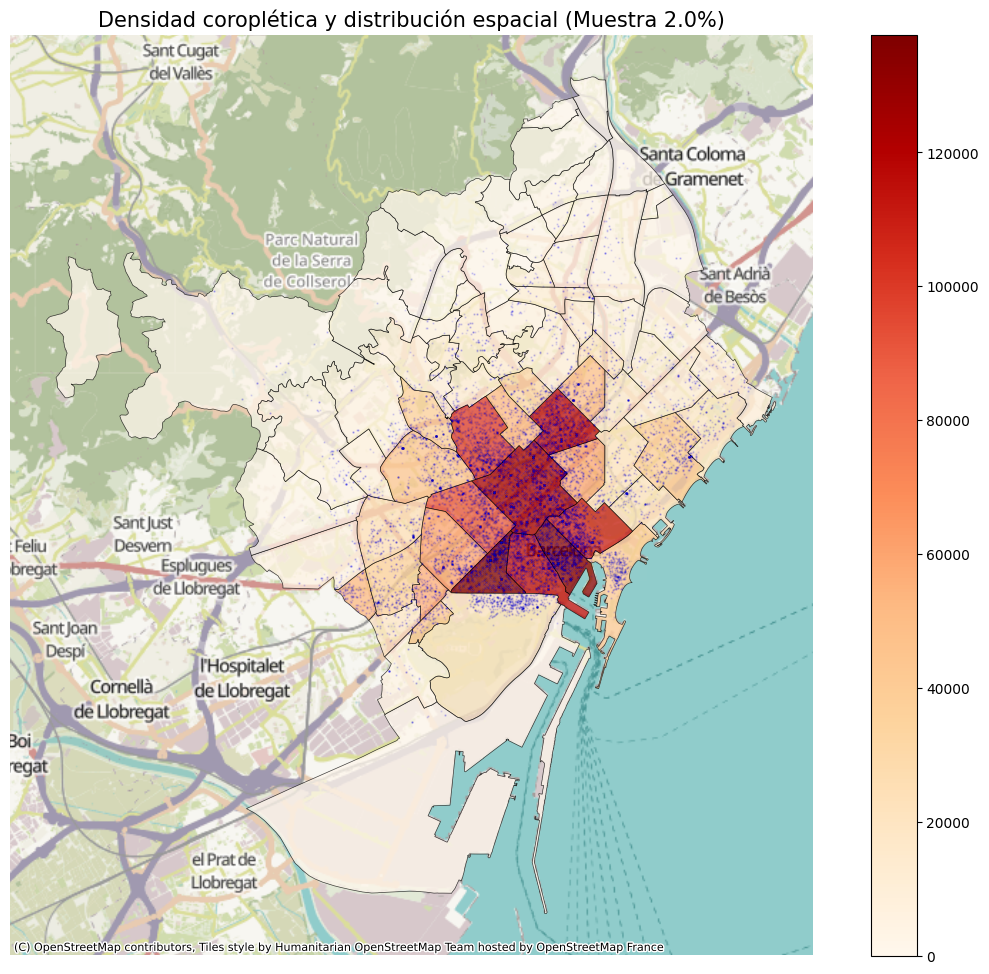

In [15]:
# 1. Calidad Tabular Base (Elimina valores erroneos)
df_dq_base = base_validator.run_all(df_raw)

# 2. Identificación nulos, duplicados y outliers
df_dq_secundario = analyzer.run_all(df_dq_base)

# 3. Calidad Categórica (Estandariza textos y booleanos)
df_dq_cat = analyzer_cat.run_all(df_dq_secundario)

# 4. Calidad Temporal (Valida fechas y rangos)
df_dq_temp = analyzer_temp.run_all(df_dq_base)

# 5. Calidad Espacial (Filtros GPS, Edge Effects y MAUP)
gdf_final_clean, gdf_barrios_densidad = spatial_val.run_all(df_dq_cat, df_barrios)


In [13]:
import os

# 1. Definir la ruta completa
ruta_guardado = "./data/airbnb_bcn_clean.parquet"

# 2. Extraer solo la ruta de las carpetas y crearlas si no existen
directorio = os.path.dirname(ruta_guardado)
os.makedirs(directorio, exist_ok=True)

# 3. Guardar el archivo
gdf_final_clean.to_parquet(ruta_guardado, index=False)

print(f"Datos guardados en: {ruta_guardado}")

Datos guardados en: ./data/airbnb_bcn_clean.parquet
